Project: Clustering Assignment: Iris Dataset

📝 Clustering Assignment: Iris Dataset

🔍 Objective

Apply K-Means, Hierarchical Clustering, and DBSCAN to group flowers in the Iris dataset based on their features.

📦 Dataset

You can load the Iris dataset in either of the following ways:

🔹 Load Dataset from sklearn

from sklearn.datasets import load_iris

iris = load_iris()

Column names:

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

👉 Do not use the species column for clustering (unsupervised).

✅ What to Do

1. Data Preprocessing

    Load the dataset

    Add column names if using CSV

    Check for missing values

    Scale the features (StandardScaler)

2. EDA (Exploratory Data Analysis)

    Show basic statistics

    Plot pairplot or heatmap

3. Apply Clustering Algorithms

🔹 K-Means

    Try different k values

    Use Elbow Method to choose optimal k

    Visualize clusters (use PCA if needed)

🔹 Hierarchical Clustering

    Plot dendrogram

    Choose number of clusters

    Visualize results

🔹 DBSCAN

    Use k-distance graph to find eps

    Show clusters & noise points

    Visualize results

4. Evaluation (Optional but encouraged)

    Compare cluster labels to actual species

    Use Confusion Matrix or Adjusted Rand Index

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()

In [ ]:
import pandas as pd

# Convert to dataframe to easily check for missing values
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Check for missing values
print("Missing values per column:")
print(iris_df.isnull().sum())

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(iris_df)

# Display the first few rows of the scaled features
print("\nScaled Features (first 5 rows):")
print(scaled_features[:5])


Scaled Features (first 5 rows):
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert scaled features back to a DataFrame for easier analysis and visualization
scaled_df = pd.DataFrame(scaled_features, columns=iris.feature_names)

# Show basic statistics of scaled features
print("Basic statistics of scaled features:")
display(scaled_df.describe())

Basic statistics of scaled features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-1.468455e-15,-1.823726e-15,-1.610564e-15,-9.473903e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00



Pairplot of scaled features:


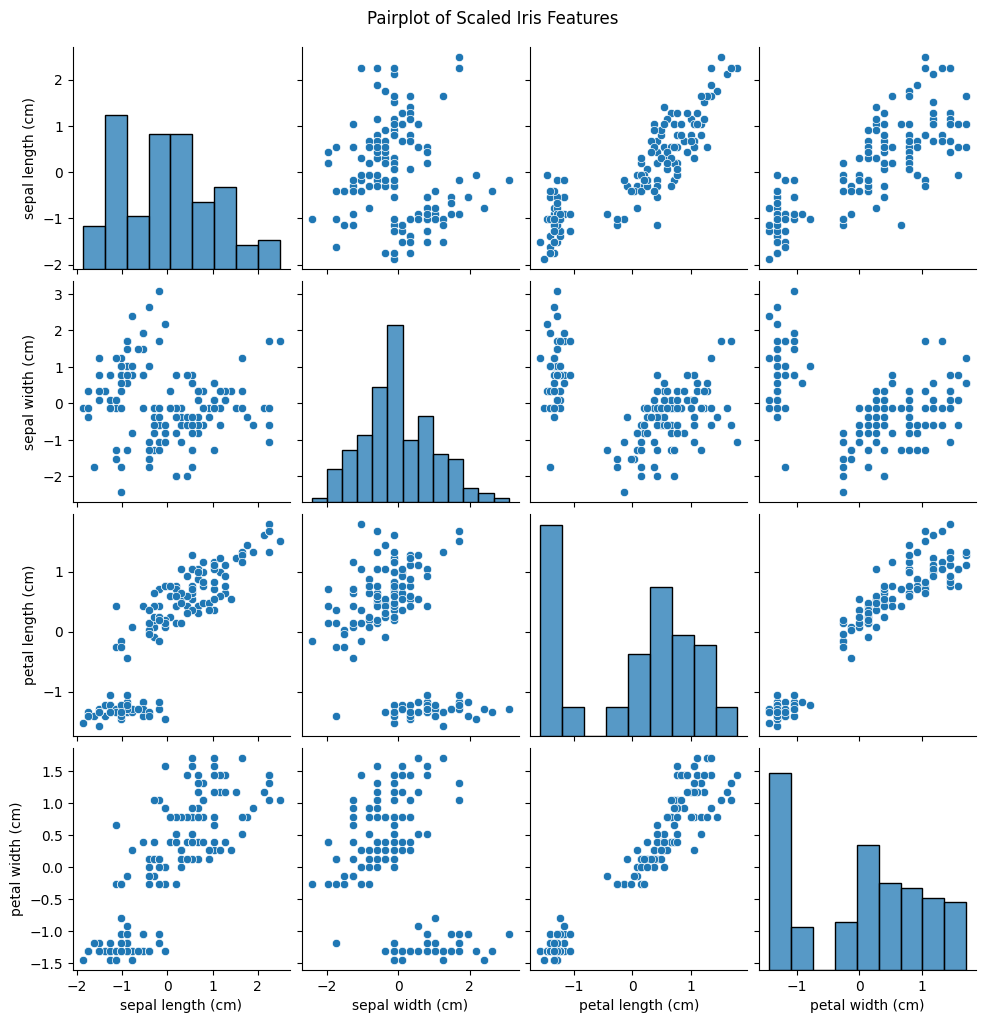

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot pairplot of scaled features
print("\nPairplot of scaled features:")
sns.pairplot(scaled_df)
plt.suptitle("Pairplot of Scaled Iris Features", y=1.02)
plt.show()

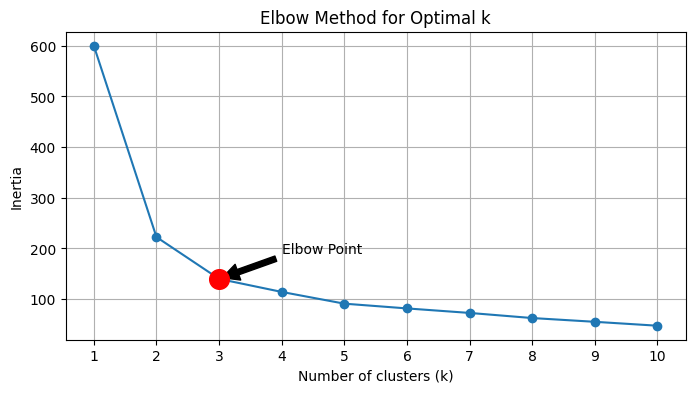

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Determine the optimal number of clusters using the Elbow Method
inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 4))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)

# Highlight the elbow point (assuming k=3 based on the previous output)
elbow_k = 3
plt.annotate('Elbow Point', xy=(elbow_k, inertia[elbow_k - 1]), xytext=(elbow_k + 1, inertia[elbow_k - 1] + 50),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10, color='black')
plt.scatter(elbow_k, inertia[elbow_k - 1], color='red', s=200, label='Elbow Point', zorder=5)

plt.show()

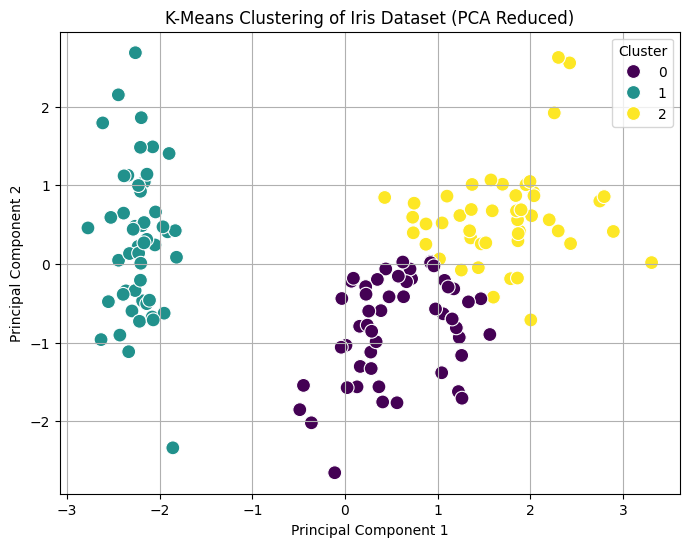

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply K-Means with the optimal number of clusters (k=3)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(scaled_features)

# Reduce dimensions to 2D for visualization using PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

# Create a DataFrame for the principal components and cluster labels
pca_df = pd.DataFrame(data=principal_components, columns=['principal component 1', 'principal component 2'])
pca_df['cluster'] = kmeans_labels

# Visualize the K-Means clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='principal component 1', y='principal component 2', hue='cluster', data=pca_df, palette='viridis', s=100)
plt.title('K-Means Clustering of Iris Dataset (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

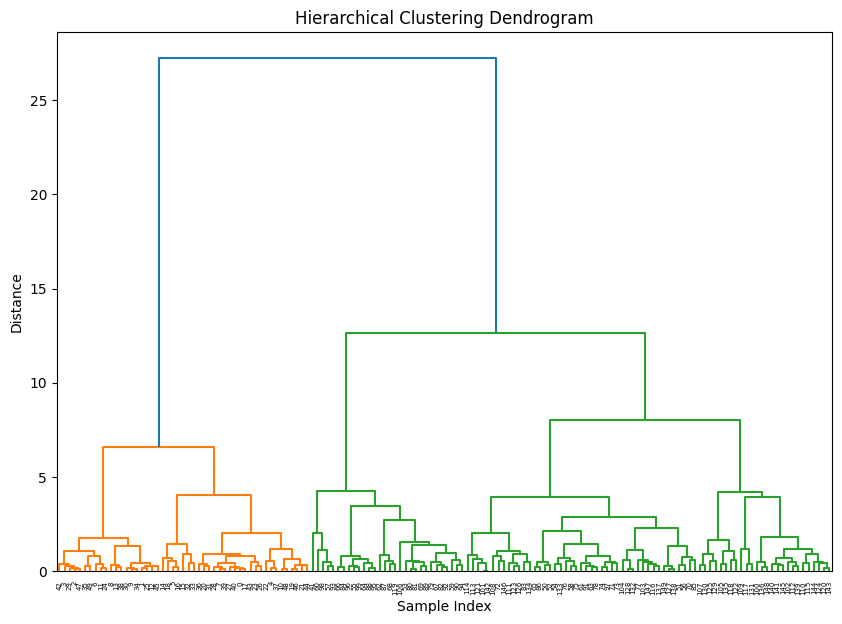

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Plot the dendrogram to help choose the number of clusters
plt.figure(figsize=(10, 7))
dendrogram(linkage(scaled_features, method='ward'))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

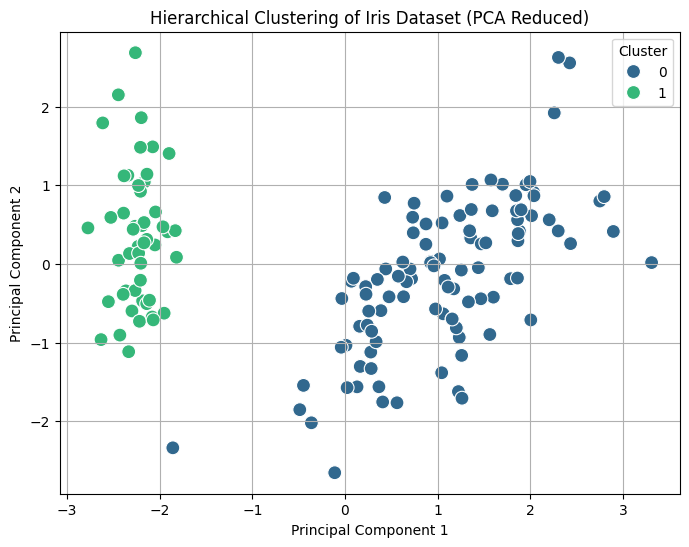

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Apply Hierarchical Clustering with 2 clusters
n_clusters_hierarchical = 2
hierarchical_clustering = AgglomerativeClustering(n_clusters=n_clusters_hierarchical)
hierarchical_labels = hierarchical_clustering.fit_predict(scaled_features)

# Reduce dimensions to 2D for visualization using PCA (re-using the existing PCA object or creating a new one)
# Re-using the existing pca object fitted on scaled_features
principal_components_hierarchical = pca.transform(scaled_features)

# Create a DataFrame for the principal components and cluster labels
pca_df_hierarchical = pd.DataFrame(data=principal_components_hierarchical, columns=['principal component 1', 'principal component 2'])
pca_df_hierarchical['cluster'] = hierarchical_labels

# Visualize the Hierarchical clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='principal component 1', y='principal component 2', hue='cluster', data=pca_df_hierarchical, palette='viridis', s=100)
plt.title('Hierarchical Clustering of Iris Dataset (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

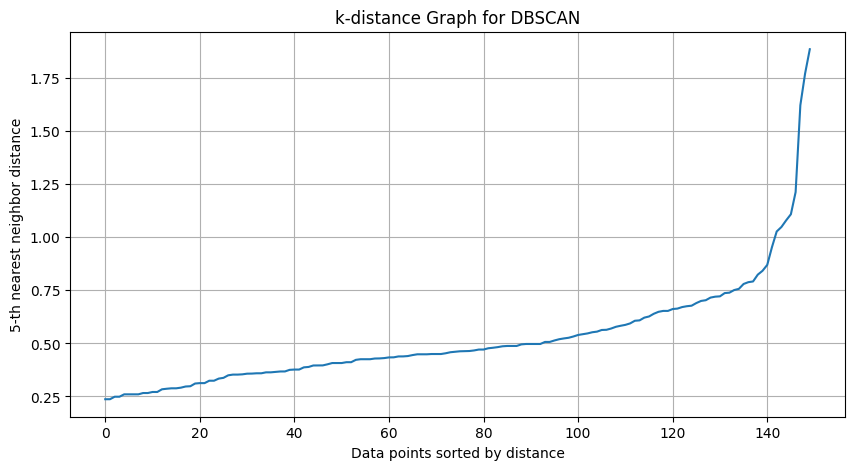

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Use k-distance graph to find optimal eps
# Typically, min_samples is set to 2 * number of dimensions
# For the Iris dataset with 4 features, we can start with min_samples = 8 (2 * 4) or try other values like 5
min_samples = 5 # Let's use a common value for min_samples

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(scaled_features)
distances, indices = neighbors_fit.kneighbors(scaled_features)

# Sort distances and plot
distances = np.sort(distances[:, min_samples-1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('k-distance Graph for DBSCAN')
plt.xlabel('Data points sorted by distance')
plt.ylabel(f'{min_samples}-th nearest neighbor distance')
plt.grid(True)
plt.show()

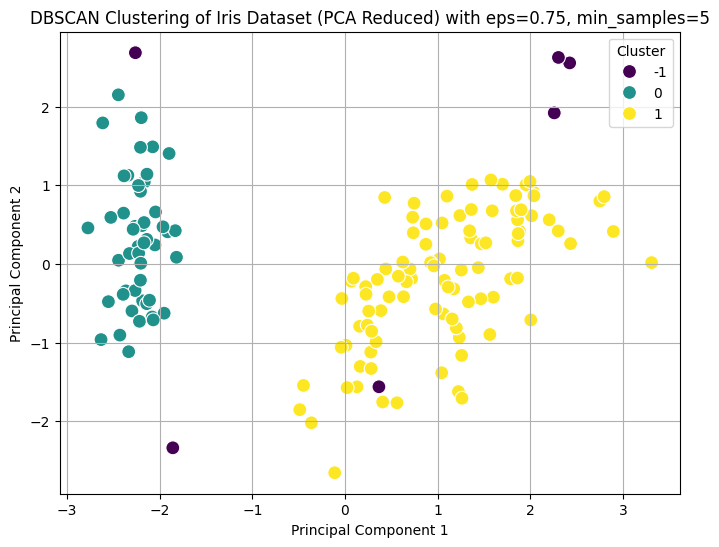


Number of clusters found: 2
Number of noise points: 6


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Apply DBSCAN with the chosen eps and min_samples
eps_value = 0.75
min_samples_value = 5 # Using the same min_samples as used for the k-distance graph

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
dbscan_labels = dbscan.fit_predict(scaled_features)

# Reduce dimensions to 2D for visualization using PCA (re-using the existing PCA object)
principal_components_dbscan = pca.transform(scaled_features)

# Create a DataFrame for the principal components and cluster labels
pca_df_dbscan = pd.DataFrame(data=principal_components_dbscan, columns=['principal component 1', 'principal component 2'])
pca_df_dbscan['cluster'] = dbscan_labels

# Visualize the DBSCAN clusters and noise points
plt.figure(figsize=(8, 6))
sns.scatterplot(x='principal component 1', y='principal component 2', hue='cluster', data=pca_df_dbscan, palette='viridis', s=100, legend='full')
plt.title(f'DBSCAN Clustering of Iris Dataset (PCA Reduced) with eps={eps_value}, min_samples={min_samples_value}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# Print the number of clusters found (excluding noise points)
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f'\nNumber of clusters found: {n_clusters}')
print(f'Number of noise points: {n_noise}')

In [ ]:
from sklearn.metrics import adjusted_rand_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# The actual species labels are in iris.target
true_labels = iris.target

print("Evaluation of Clustering Results:\n")

# Evaluate K-Means
print("K-Means Clustering Evaluation:")
# Note: K-Means cluster labels might not directly correspond to species labels (e.g., cluster 0 could be species 1).
# Adjusted Rand Index measures the similarity between two clusterings, ignoring permutations.
ari_kmeans = adjusted_rand_score(true_labels, kmeans_labels)
print(f"Adjusted Rand Index: {ari_kmeans:.4f}")

# Confusion Matrix for K-Means (requires mapping cluster labels to species labels for interpretation)
# A simple way to visualize is to see how many points from each true class fall into each cluster.
# This is not a standard confusion matrix but helps understand the mapping.
km_conf_matrix = pd.crosstab(true_labels, kmeans_labels, rownames=['Actual Species'], colnames=['K-Means Cluster'])
print("\nConfusion Matrix (Actual Species vs. K-Means Cluster):")
display(km_conf_matrix)


# Evaluate Hierarchical Clustering
print("\nHierarchical Clustering Evaluation:")
# Note: Hierarchical cluster labels might also not directly correspond to species labels.
ari_hierarchical = adjusted_rand_score(true_labels, hierarchical_labels)
print(f"Adjusted Rand Index: {ari_hierarchical:.4f}")

# Confusion Matrix for Hierarchical Clustering
hierarchical_conf_matrix = pd.crosstab(true_labels, hierarchical_labels, rownames=['Actual Species'], colnames=['Hierarchical Cluster'])
print("\nConfusion Matrix (Actual Species vs. Hierarchical Cluster):")
display(hierarchical_conf_matrix)


# Evaluate DBSCAN
print("\nDBSCAN Clustering Evaluation:")
# Note: DBSCAN might produce noise points (-1 label) and the number of clusters can vary.
# Adjusted Rand Index can handle noise points.
ari_dbscan = adjusted_rand_score(true_labels, dbscan_labels)
print(f"Adjusted Rand Index: {ari_dbscan:.4f}")

# Confusion Matrix for DBSCAN (including noise points)
dbscan_conf_matrix = pd.crosstab(true_labels, dbscan_labels, rownames=['Actual Species'], colnames=['DBSCAN Cluster'])
print("\nConfusion Matrix (Actual Species vs. DBSCAN Cluster):")
display(dbscan_conf_matrix)

Evaluation of Clustering Results:

K-Means Clustering Evaluation:
Adjusted Rand Index: 0.6201

Confusion Matrix (Actual Species vs. K-Means Cluster):


K-Means Cluster,0,1,2
Actual Species,,,
0,0,50,0
1,39,0,11
2,14,0,36



Hierarchical Clustering Evaluation:
Adjusted Rand Index: 0.5438

Confusion Matrix (Actual Species vs. Hierarchical Cluster):


Hierarchical Cluster,0,1
Actual Species,,
0,1,49
1,50,0
2,50,0



DBSCAN Clustering Evaluation:
Adjusted Rand Index: 0.5401

Confusion Matrix (Actual Species vs. DBSCAN Cluster):


DBSCAN Cluster,-1,0,1
Actual Species,,,
0,2,48,0
1,0,0,50
2,4,0,46


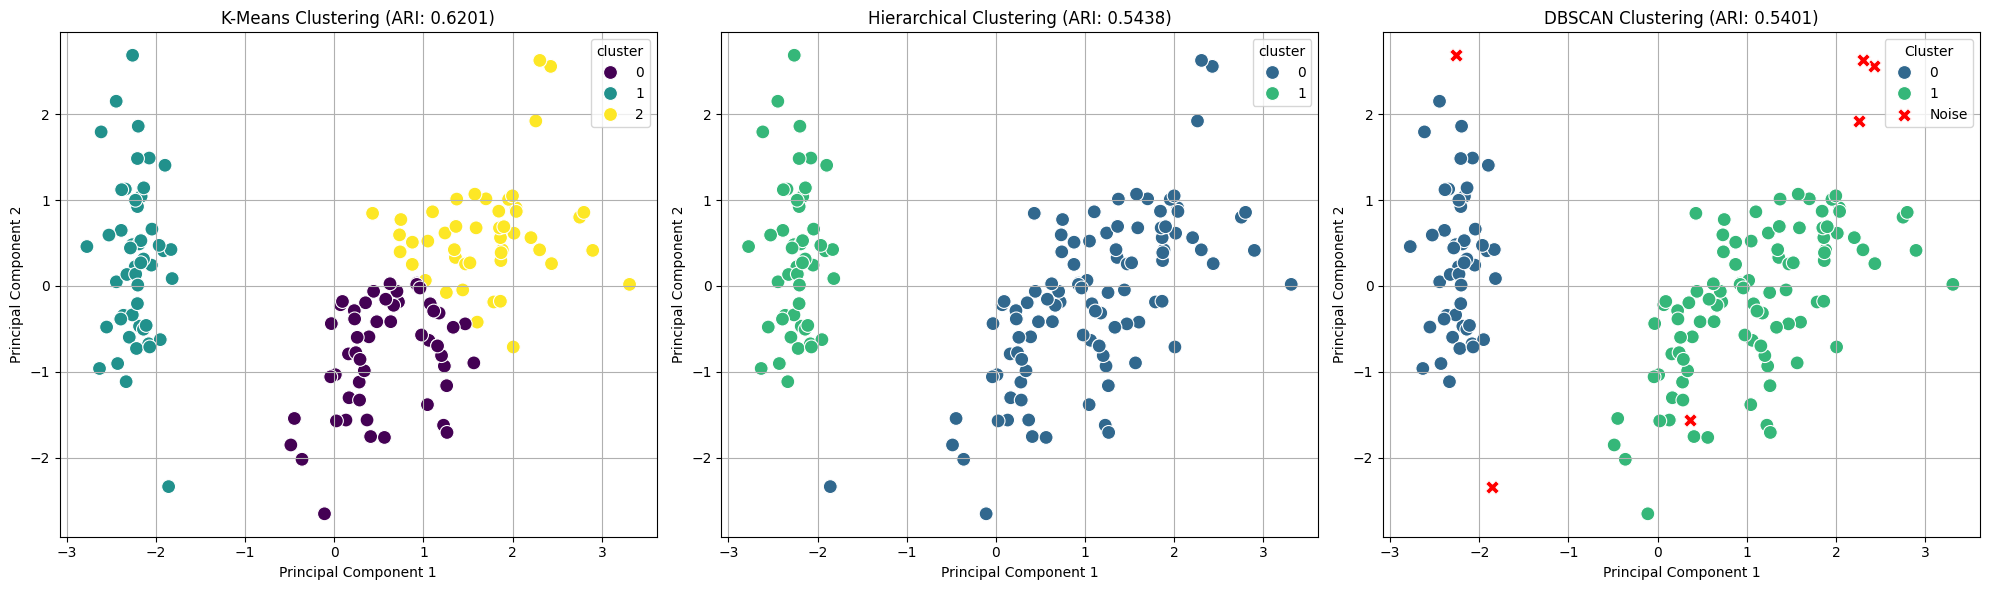

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot K-Means clusters
sns.scatterplot(ax=axes[0], x='principal component 1', y='principal component 2', hue='cluster', data=pca_df, palette='viridis', s=100)
axes[0].set_title(f'K-Means Clustering (ARI: {ari_kmeans:.4f})')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].grid(True)

# Plot Hierarchical clusters
sns.scatterplot(ax=axes[1], x='principal component 1', y='principal component 2', hue='cluster', data=pca_df_hierarchical, palette='viridis', s=100)
axes[1].set_title(f'Hierarchical Clustering (ARI: {ari_hierarchical:.4f})')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].grid(True)

# Plot DBSCAN clusters and noise points
# Separate noise points (-1) for different marker style
pca_df_dbscan_clusters = pca_df_dbscan[pca_df_dbscan['cluster'] != -1]
pca_df_dbscan_noise = pca_df_dbscan[pca_df_dbscan['cluster'] == -1]

sns.scatterplot(ax=axes[2], x='principal component 1', y='principal component 2', hue='cluster', data=pca_df_dbscan_clusters, palette='viridis', s=100, legend='full')
sns.scatterplot(ax=axes[2], x='principal component 1', y='principal component 2', data=pca_df_dbscan_noise, color='red', marker='X', s=100, label='Noise') # Plot noise in red with 'X' marker
axes[2].set_title(f'DBSCAN Clustering (ARI: {ari_dbscan:.4f})')
axes[2].set_xlabel('Principal Component 1')
axes[2].set_ylabel('Principal Component 2')
axes[2].grid(True)
axes[2].legend(title='Cluster')

plt.tight_layout()
plt.show()

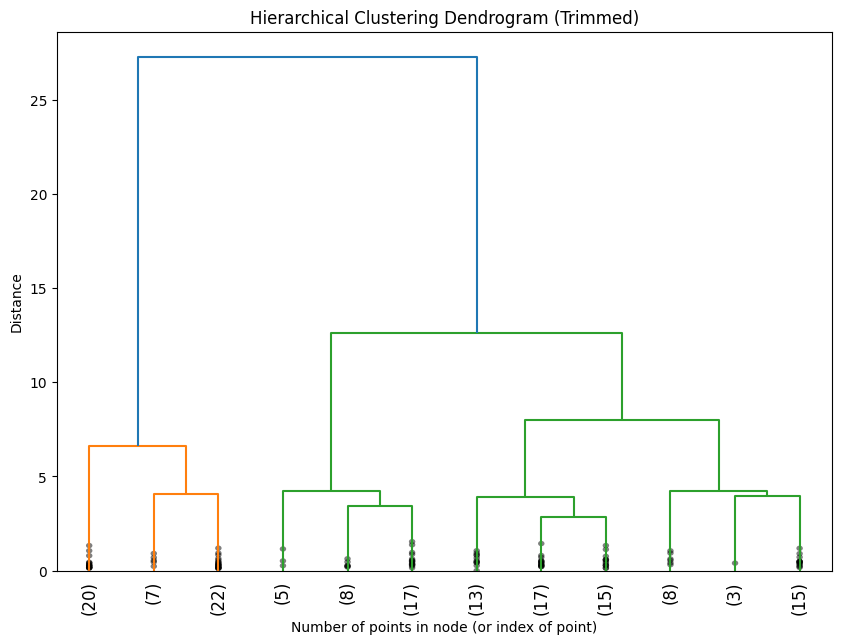

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Generate the linkage matrix
linked = linkage(scaled_features, method='ward')

# Plot the trimmed dendrogram to help choose the number of clusters
plt.figure(figsize=(10, 7))
dendrogram(linked,
           truncate_mode='lastp', # Show only the last p merged clusters
           p=12, # Display the last 12 merged clusters (adjust as needed)
           show_leaf_counts=True,
           leaf_rotation=90.,
           leaf_font_size=12.,
           show_contracted=True, # To show the number of points in the contracted nodes
           )
plt.title('Hierarchical Clustering Dendrogram (Trimmed)')
plt.xlabel('Number of points in node (or index of point)')
plt.ylabel('Distance')

# You can visually inspect the dendrogram to decide on the number of clusters.
# For example, to show 2 clusters, you can draw a horizontal line at a certain distance.
# Let's find the height to cut for 2 clusters (visual inspection from the plot)
# If you want to highlight a specific number of clusters, you might need to determine the distance threshold.
# As an example, let's assume we want to highlight 2 clusters:
# max_d = 10 # Example distance threshold - you'd choose this based on the dendrogram
# plt.axhline(y=max_d, color='r', linestyle='--', label=f'{2} Clusters cut')
# plt.legend()

plt.show()

# You can also use fcluster to get the cluster assignments for a chosen number of clusters
# clusters = fcluster(linked, 2, criterion='maxclust')
# print(f"Cluster assignments for 2 clusters (first 10): {clusters[:10]}")

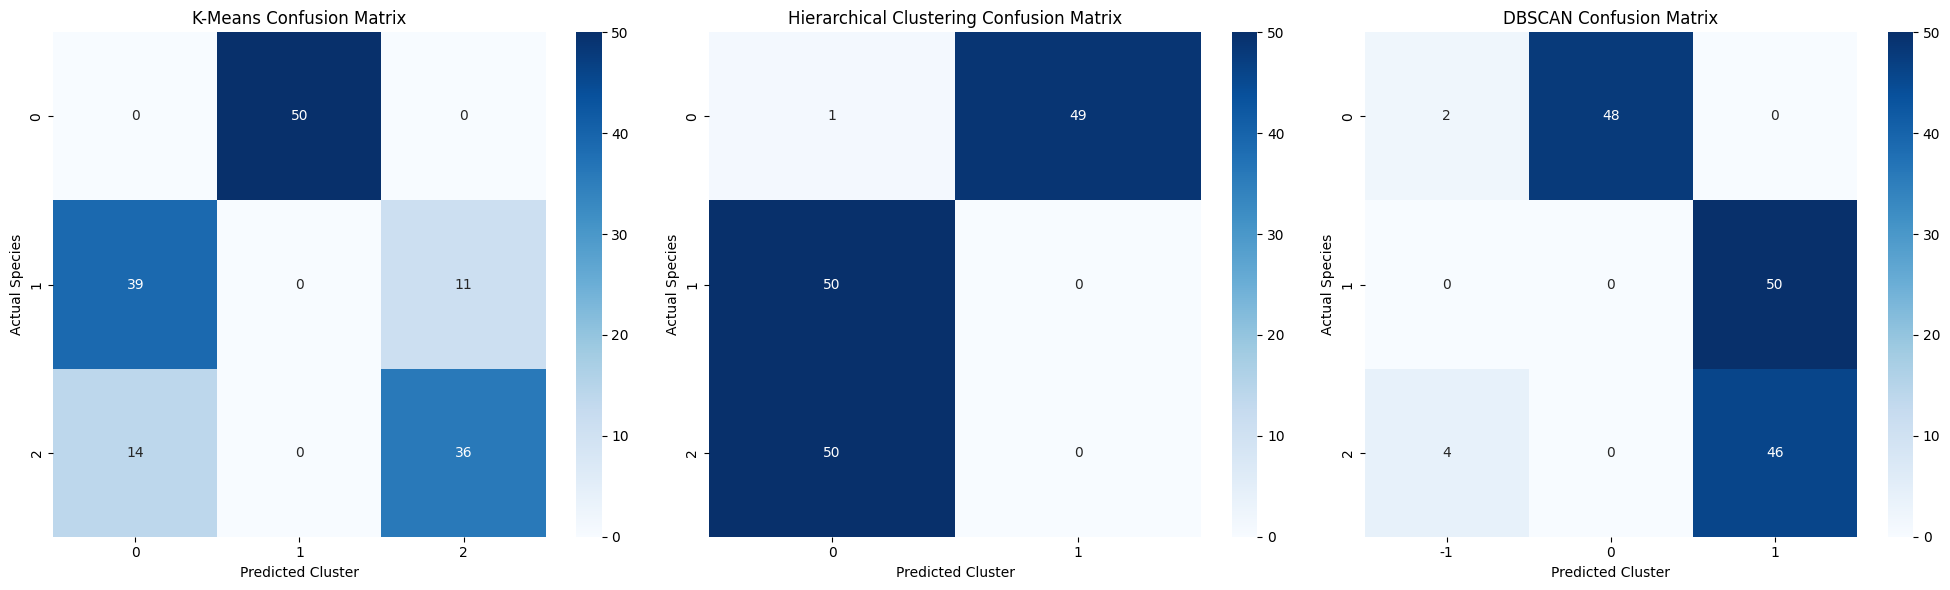

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a figure with three subplots for the heatmaps
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# K-Means Confusion Matrix Heatmap
sns.heatmap(km_conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('K-Means Confusion Matrix')
axes[0].set_xlabel('Predicted Cluster')
axes[0].set_ylabel('Actual Species')

# Hierarchical Clustering Confusion Matrix Heatmap
sns.heatmap(hierarchical_conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Hierarchical Clustering Confusion Matrix')
axes[1].set_xlabel('Predicted Cluster')
axes[1].set_ylabel('Actual Species')

# DBSCAN Confusion Matrix Heatmap
sns.heatmap(dbscan_conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('DBSCAN Confusion Matrix')
axes[2].set_xlabel('Predicted Cluster')
axes[2].set_ylabel('Actual Species')

plt.tight_layout()
plt.show()

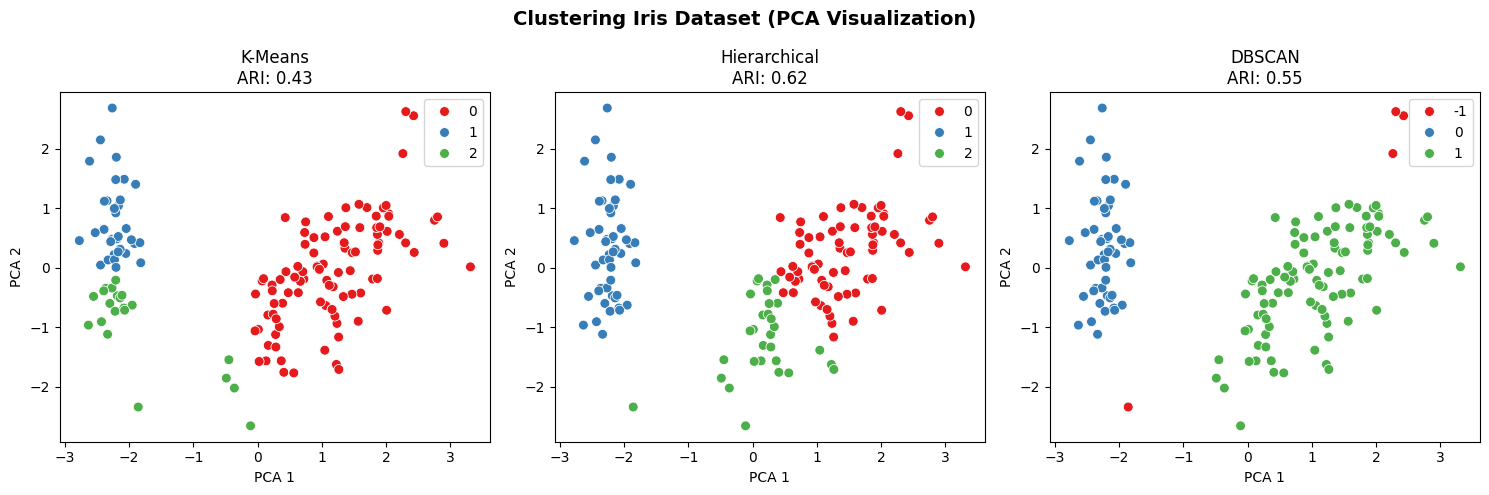

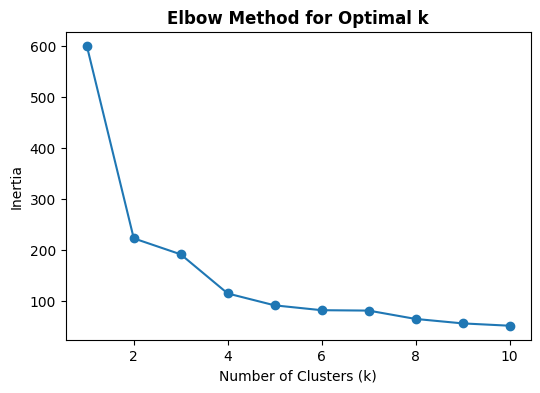

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import adjusted_rand_score, confusion_matrix
import numpy as np

# Load and scale data
iris = load_iris()
X = iris.data
y = iris.target
X_scaled = StandardScaler().fit_transform(X)

# Dimensionality reduction for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Clustering models
models = {
    "K-Means": KMeans(n_clusters=3, random_state=42),
    "Hierarchical": AgglomerativeClustering(n_clusters=3),
    "DBSCAN": DBSCAN(eps=0.8, min_samples=5)
}

results = {}

# Apply clustering and evaluate
for name, model in models.items():
    labels = model.fit_predict(X_scaled)
    ari = adjusted_rand_score(y, labels)
    results[name] = {"labels": labels, "ARI": ari}

# Plot PCA scatterplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, result) in zip(axes, results.items()):
    sns.scatterplot(
        x=X_pca[:, 0],
        y=X_pca[:, 1],
        hue=result["labels"],
        palette="Set1",
        legend="full",
        s=50,
        ax=ax
    )
    ax.set_title(f"{name}\nARI: {result['ARI']:.2f}")
    ax.set_xlabel("PCA 1")
    ax.set_ylabel("PCA 2")

plt.suptitle("Clustering Iris Dataset (PCA Visualization)", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

# Optional: Elbow method for K-Means
inertia = []
k_values = range(1, 11)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_values, inertia, marker="o")
plt.title("Elbow Method for Optimal k", fontsize=12, weight="bold")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()